<a href="https://colab.research.google.com/github/Deepthi-1534/MACHINE-LEARNING-LAB/blob/main/KNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Preview:
       age  menopause tumor_size inv_nodes node_caps deg_malig   breast  \
0  '40-49'  'premeno'    '15-19'     '0-2'     'yes'       '3'  'right'   
1  '50-59'     'ge40'    '15-19'     '0-2'      'no'       '1'  'right'   
2  '50-59'     'ge40'    '35-39'     '0-2'      'no'       '2'   'left'   
3  '40-49'  'premeno'    '35-39'     '0-2'     'yes'       '3'  'right'   
4  '40-49'  'premeno'    '30-34'     '3-5'     'yes'       '2'   'left'   

  breast_quad irradiat                   class  
0   'left_up'     'no'     'recurrence-events'  
1   'central'     'no'  'no-recurrence-events'  
2  'left_low'     'no'     'recurrence-events'  
3  'left_low'    'yes'  'no-recurrence-events'  
4  'right_up'     'no'     'recurrence-events'  

Accuracy: 0.7758620689655172

Confusion Matrix:
[[39  1]
 [12  6]]

Classification Report:
                        precision    recall  f1-score   support

'no-recurrence-events'       0.76      0.97      0.86        40
   'recurrence-ev

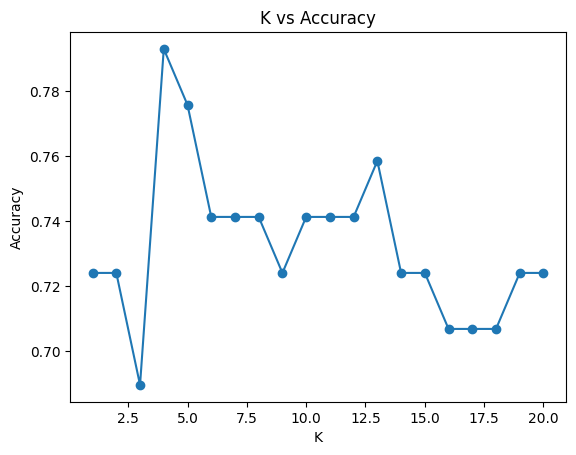

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/breast-cancer.csv"


columns = [
    "age", "menopause", "tumor_size", "inv_nodes", "node_caps",
    "deg_malig", "breast", "breast_quad", "irradiat", "class"
]

df = pd.read_csv(url, names=columns)

print("Dataset Preview:")
print(df.head())


X = df.drop("class", axis=1)
y = df["class"]


X = pd.get_dummies(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


accuracy_scores = []

for k in range(1, 21):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    preds = knn.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, preds))

# Plot
plt.plot(range(1, 21), accuracy_scores, marker='o')
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")
plt.show()